In [1]:
import zipfile
import pandas as pd

# 1. Zip file-ah automatic-ah extract panrom
with zipfile.ZipFile('/content/archive (4).zip', 'r') as zip_ref:
    zip_ref.extractall('/content/')

# 2. Extract aana csv file-ah read panrom
df = pd.read_csv('/content/USA_Housing.csv')

# 3. Data success-ah load aayiduchanu first 5 rows paakrom
df.head()

,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price,Address
0,79545.458574,5.682861,7.009188,4.09,23086.800503,1.059034e+06,"208 Michael Ferry Apt. 674\nLaurabury, NE 3701..."
1,79248.642455,6.002900,6.730821,3.09,40173.072174,1.505891e+06,"188 Johnson Views Suite 079\nLake Kathleen, CA..."
2,61287.067179,5.865890,8.512727,5.13,36882.159400,1.058988e+06,"9127 Elizabeth Stravenue\nDanieltown, WI 06482..."
3,63345.240046,7.188236,5.586729,3.26,34310.242831,1.260617e+06,USS Barnett\nFPO AP 44820
4,59982.197226,5.040555,7.839388,4.23,26354.109472,6.309435e+05,USNS Raymond\nFPO AE 09386


In [2]:
# 1. Unnecessary 'Address' column-ah drop panrom
df_clean = df.drop(['Address'], axis=1)

# 2. X (Features) and y (Target) pirikrom
# Price column thavira balance ellam X
X = df_clean.drop(['Price'], axis=1)

# Price column mattum y (Target)
y = df_clean['Price']

print("Professional Features (X) Columns:\n", X.columns.tolist())
print("\nShape of X (Rows, Columns):", X.shape)

Professional Features (X) Columns:
 ['Avg. Area Income', 'Avg. Area House Age', 'Avg. Area Number of Rooms', 'Avg. Area Number of Bedrooms', 'Area Population']

Shape of X (Rows, Columns): (5000, 5)


In [3]:
from sklearn.model_selection import train_test_split

# Real data-va 80% training and 20% testing-nu split panrom
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Professional Training rows:", X_train.shape[0])
print("Professional Testing rows:", X_test.shape[0])

Professional Training rows: 4000
Professional Testing rows: 1000


In [4]:
from sklearn.linear_model import LinearRegression

# 1. Real Linear Regression model-ah initialize panrom
real_model = LinearRegression()

# 2. 4000 rows of real data-va vachu model-ah train panrom
real_model.fit(X_train, y_train)

print("Professional ML Model trained successfully with 4000 rows!")

Professional ML Model trained successfully with 4000 rows!


In [5]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# 1. 1000 testing records-uku price predict panrom
y_pred = real_model.predict(X_test)

# 2. Professional Metrics Calculate panrom
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"Professional Model Metrics:")
print(f"---------------------------")
print(f"Mean Absolute Error (MAE) : ${mae:,.2f}")
print(f"Root Mean Squared Error (RMSE): ${rmse:,.2f}")
print(f"R² Score (Accuracy Percentage): {r2*100:.2f}%")

Professional Model Metrics:
---------------------------
Mean Absolute Error (MAE) : $80,879.10
Root Mean Squared Error (RMSE): $100,444.06
R² Score (Accuracy Percentage): 91.80%


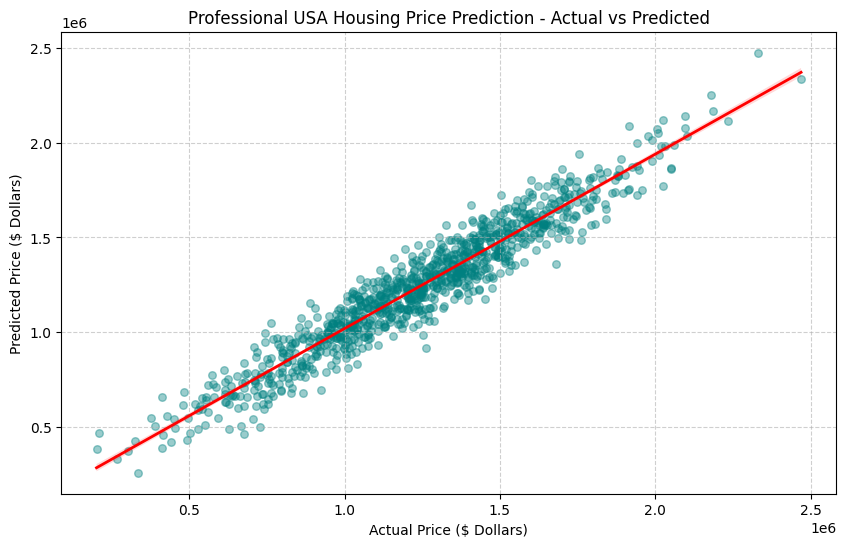

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# Graph setting details
plt.figure(figsize=(10, 6))

# 1. Regression Plot draw panrom (with a beautiful trend line)
sns.regplot(x=y_test, y=y_pred, scatter_kws={'color':'teal', 'alpha':0.4, 's':30}, line_kws={'color':'red', 'linewidth':2})

plt.xlabel("Actual Price ($ Dollars)")
plt.ylabel("Predicted Price ($ Dollars)")
plt.title("Professional USA Housing Price Prediction - Actual vs Predicted")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()